# Python: Impact of 401(k) on Financial Wealth

In this real-data example, we illustrate how the [DoubleML](https://docs.doubleml.org/stable/index.html) package can be used to estimate the effect of 401(k) eligibility and participation on accumulated assets. The 401(k) data set has been analyzed in several studies, among others [Chernozhukov et al. (2018)](https://arxiv.org/abs/1608.00060).

401(k) plans are pension accounts sponsored by employers. The key problem in determining the effect of participation in 401(k) plans on accumulated assets is saver heterogeneity coupled with the fact that the decision to enroll in a 401(k) is non-random. It is generally recognized that some people have a higher preference for saving than others. It also seems likely that those individuals with high unobserved preference for saving would be most likely to choose to participate in tax-advantaged retirement savings plans and would tend to have otherwise high amounts of accumulated assets. The presence of unobserved savings preferences with these properties then implies that conventional estimates that do not account for saver heterogeneity and endogeneity of participation will be biased upward, tending to overstate the savings effects of 401(k) participation.

One can argue that eligibility for enrolling in a 401(k) plan in this data can be taken as exogenous after conditioning on a few observables of which the most important for their argument is income. The basic idea is that, at least around the time 401(k)’s initially became available, people were unlikely to be basing their employment decisions on whether an employer offered a 401(k) but would instead focus on income and other aspects of the job.

## Data

The preprocessed data can be fetched by calling [fetch_401K()](https://docs.doubleml.org/stable/api/generated/doubleml.datasets.fetch_401K.html#doubleml.datasets.fetch_401K). Note that an internet connection is required for loading the data.

In [1]:
import numpy as np
import pandas as pd
import doubleml as dml
from doubleml.datasets import fetch_401K

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LassoCV, LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from xgboost import XGBClassifier, XGBRegressor

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set()
colors = sns.color_palette()

In [3]:
plt.rcParams['figure.figsize'] = 10., 7.5
sns.set(font_scale=1.5)
sns.set_style('whitegrid', {'axes.spines.top': False,
                            'axes.spines.bottom': False,
                            'axes.spines.left': False,
                            'axes.spines.right': False})

In [4]:
data = fetch_401K(return_type='DataFrame')

In [5]:
print(data.head())

      nifa  net_tfa        tw  age      inc  fsize  educ  db  marr  twoearn  \
0      0.0      0.0    4500.0   47   6765.0      2     8   0     0        0   
1   6215.0   1015.0   22390.0   36  28452.0      1    16   0     0        0   
2      0.0  -2000.0   -2000.0   37   3300.0      6    12   1     0        0   
3  15000.0  15000.0  155000.0   58  52590.0      2    16   0     1        1   
4      0.0      0.0   58000.0   32  21804.0      1    11   0     0        0   

   e401  p401  pira  hown  
0     0     0     0     1  
1     0     0     0     1  
2     0     0     0     0  
3     0     0     0     1  
4     0     0     0     1  


In [6]:
print(data.describe())

               nifa       net_tfa            tw          age            inc  \
count  9.915000e+03  9.915000e+03  9.915000e+03  9915.000000    9915.000000   
mean   1.392864e+04  1.805153e+04  6.381684e+04    41.060212   37200.621094   
std    5.490488e+04  6.352250e+04  1.115297e+05    10.344505   24774.289062   
min    0.000000e+00 -5.023020e+05 -5.023020e+05    25.000000   -2652.000000   
25%    2.000000e+02 -5.000000e+02  3.291500e+03    32.000000   19413.000000   
50%    1.635000e+03  1.499000e+03  2.510000e+04    40.000000   31476.000000   
75%    8.765500e+03  1.652450e+04  8.148750e+04    48.000000   48583.500000   
max    1.430298e+06  1.536798e+06  2.029910e+06    64.000000  242124.000000   

             fsize         educ           db         marr      twoearn  \
count  9915.000000  9915.000000  9915.000000  9915.000000  9915.000000   
mean      2.865860    13.206253     0.271004     0.604841     0.380837   
std       1.538937     2.810382     0.444500     0.488909     0.48

The data consist of 9,915 observations at the household level drawn from the 1991 Survey of Income and Program Participation (SIPP).  All the variables are referred to 1990. We use net financial assets (*net\_tfa*) as the outcome variable, $Y$,  in our analysis. The net financial assets are computed as the sum of IRA balances, 401(k) balances, checking accounts, saving bonds, other interest-earning accounts, other interest-earning assets, stocks, and mutual funds less non mortgage debts. 

Among the $9915$ individuals, $3682$ are eligible to participate in the program. The variable *e401* indicates eligibility and *p401* indicates participation, respectively.

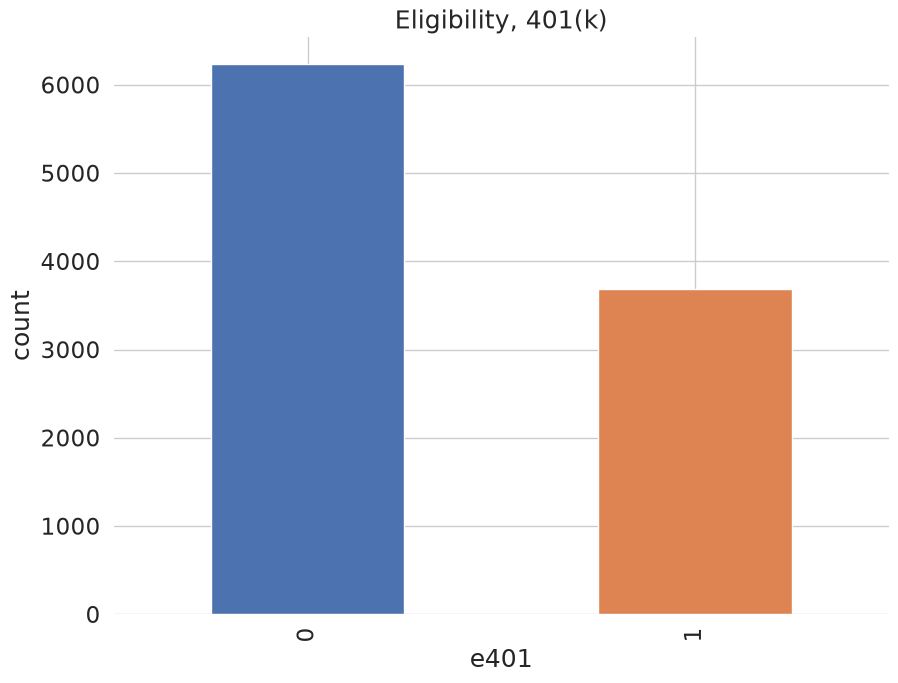

In [7]:
data['e401'].value_counts().plot(kind='bar', color=colors)
plt.title('Eligibility, 401(k)')
plt.xlabel('e401')
_ = plt.ylabel('count')

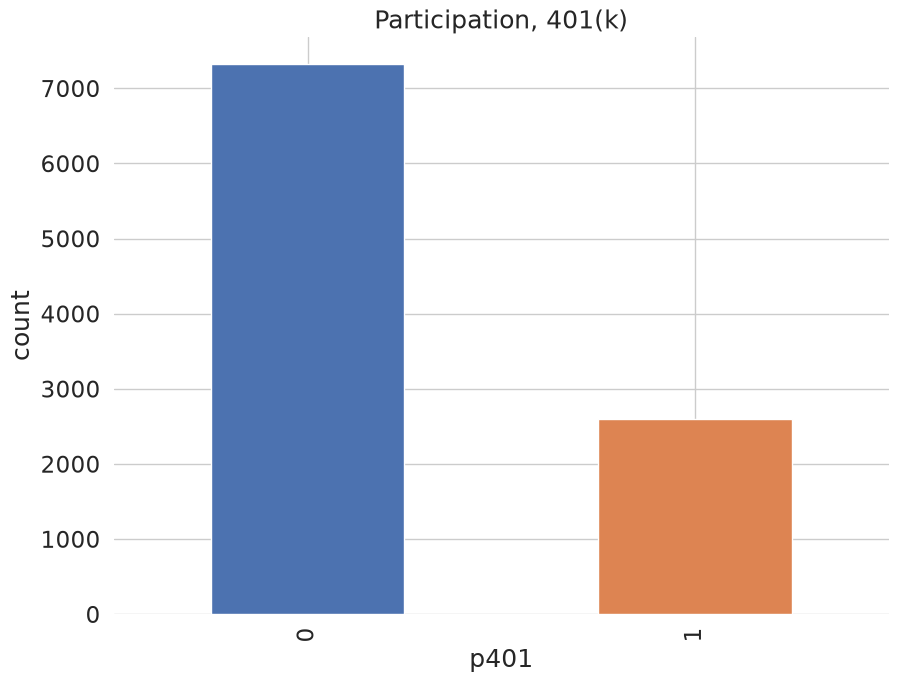

In [8]:
data['p401'].value_counts().plot(kind='bar', color=colors)
plt.title('Participation, 401(k)')
plt.xlabel('p401')
_ = plt.ylabel('count')

Eligibility is highly associated with financial wealth:

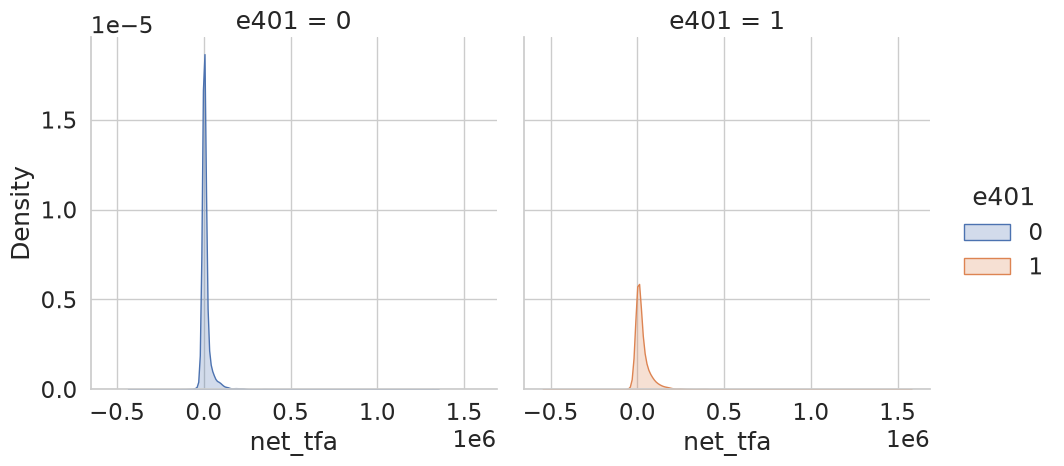

In [9]:
_ = sns.displot(data, x="net_tfa", hue="e401", col="e401",
                kind="kde", fill=True)

As a first estimate, we calculate the unconditional average predictive effect (APE) of 401(k) eligibility on accumulated assets. This effect corresponds to the average treatment effect if 401(k) eligibility would be assigned to individuals in an entirely randomized way. The unconditional APE of e401 is about $19559$:

In [10]:
print(data[['e401', 'net_tfa']].groupby('e401').mean().diff())

          net_tfa
e401             
0             NaN
1     19559.34375


Among the $3682$ individuals that  are eligible, $2594$ decided to participate in the program. The unconditional APE of p401 is about $27372$:

In [11]:
print(data[['p401', 'net_tfa']].groupby('p401').mean().diff())

           net_tfa
p401              
0              NaN
1     27371.582031


As discussed, these estimates are biased since they do not account for saver heterogeneity and endogeneity of participation.

## The `DoubleML` package

Let's use the package [DoubleML](https://docs.doubleml.org/stable/index.html) to estimate the average treatment effect of 401(k) eligibility, i.e. `e401`, and participation, i.e. `p401`, on net financial assets `net_tfa`.

## Estimating the Average Treatment Effect of 401(k) Eligibility on Net Financial Assets

We first look at the treatment effect of `e401` on net total financial assets. We give estimates of the ATE in the linear model

$$
\begin{equation*}
Y = D \alpha + f(X)'\beta+ \epsilon,
\end{equation*}
$$

where $f(X)$ is a dictonary applied to the raw regressors. $X$ contains variables on marital status, two-earner status, defined benefit pension status, IRA participation, home ownership, family size, education, age, and income. 

In the following, we will consider two different models, 

* a basic model specification that includes the raw regressors, i.e., $f(X) = X$, and 

* a flexible model specification, where $f(X)$ includes the raw regressors $X$ and the orthogonal polynomials of degree 2 for the variables family size education, age, and income. 

We will use the basic model specification whenever we use nonlinear methods, for example regression trees or random forests, and use the flexible model for linear methods such as the lasso. There are, of course, multiple ways how the model can be specified even more flexibly, for example including interactions of variable and higher order interaction. However, for the sake of simplicity we stick to the specification above. Users who are interested in varying the model can adapt the code below accordingly, for example to implement the orignal specification in [Chernozhukov et al. (2018)](https://arxiv.org/abs/1608.00060). 

In the first step, we report estimates of the average treatment effect (ATE) of 401(k) eligibility on net financial assets both in the partially linear regression (PLR) model and in the interactive regression model (IRM) allowing for heterogeneous treatment effects.

### The Data Backend: `DoubleMLData`

To start our analysis, we initialize the data backend, i.e., a new instance of a [DoubleMLData](https://docs.doubleml.org/dev/api/generated/doubleml.data.DoubleMLData.html#doubleml.data.DoubleMLData) object. We implement the regression model by using scikit-learn's `PolynomialFeatures` class.

To implement both models (basic and flexible), we generate two data backends: `data_dml_base` and `data_dml_flex`.

In [12]:
# Set up basic model: Specify variables for data-backend
features_base = ['age', 'inc', 'educ', 'fsize', 'marr',
                 'twoearn', 'db', 'pira', 'hown']

# Initialize DoubleMLData (data-backend of DoubleML)
data_dml_base = dml.DoubleMLData(data,
                                 y_col='net_tfa',
                                 d_cols='e401',
                                 x_cols=features_base)

In [13]:
print(data_dml_base)

================== DoubleMLData Object ==================

------------------ Data summary      ------------------
Outcome variable: net_tfa
Treatment variable(s): ['e401']
Covariates: ['age', 'inc', 'educ', 'fsize', 'marr', 'twoearn', 'db', 'pira', 'hown']
Instrument variable(s): None
No. Observations: 9915
------------------ DataFrame info    ------------------
<class 'pandas.DataFrame'>
RangeIndex: 9915 entries, 0 to 9914
Columns: 14 entries, nifa to hown
dtypes: float32(4), int8(10)
memory usage: 251.9 KB



In [14]:
# Set up a model according to regression formula with polynomials
features = data.copy()[['marr', 'twoearn', 'db', 'pira', 'hown']]

poly_dict = {'age': 2,
             'inc': 2,
             'educ': 2,
             'fsize': 2}
for key, degree in poly_dict.items():
    poly = PolynomialFeatures(degree, include_bias=False)
    data_transf = poly.fit_transform(data[[key]])
    x_cols = poly.get_feature_names_out([key])
    data_transf = pd.DataFrame(data_transf, columns=x_cols)
    
    features = pd.concat((features, data_transf),
                          axis=1, sort=False)
model_data = pd.concat((data.copy()[['net_tfa', 'e401']], features.copy()),
                        axis=1, sort=False)

# Initialize DoubleMLData (data-backend of DoubleML)
data_dml_flex = dml.DoubleMLData(model_data, y_col='net_tfa', d_cols='e401')

In [15]:
print(data_dml_flex)

================== DoubleMLData Object ==================

------------------ Data summary      ------------------
Outcome variable: net_tfa
Treatment variable(s): ['e401']
Covariates: ['marr', 'twoearn', 'db', 'pira', 'hown', 'age', 'age^2', 'inc', 'inc^2', 'educ', 'educ^2', 'fsize', 'fsize^2']
Instrument variable(s): None
No. Observations: 9915
------------------ DataFrame info    ------------------
<class 'pandas.DataFrame'>
RangeIndex: 9915 entries, 0 to 9914
Columns: 15 entries, net_tfa to fsize^2
dtypes: float32(3), float64(6), int8(6)
memory usage: 639.2 KB



### Partially Linear Regression Model (PLR)

We start using lasso to estimate the function $g_0$ and $m_0$ in the following PLR model:

$$
\begin{aligned}
& Y = D\theta_0 + g_0(X) + \zeta, &\quad E[\zeta \mid D,X]= 0,\\
& D = m_0(X) +  V, &\quad E[V \mid X] = 0.
\end{aligned}
$$

To estimate the causal parameter $\theta_0$ here, we use double machine learning with 3-fold cross-fitting. 
 
Estimation of the nuisance components $g_0$ and $m_0$, is based on the lasso with cross-validated choice of the penalty term , $\lambda$, as provided by [scikit-learn](https://scikit-learn.org). We load the learner by initializing instances from the classes [LassoCV](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LassoCV.html) and [LogisticRegressionCV](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegressionCV.html). Hyperparameters and options can be set during instantiation of the learner. Here we specify that the lasso should use that value of $\lambda$ that minimizes the cross-validated mean squared error which is based on 5-fold cross validation.

We start by estimation the ATE in the basic model and then repeat the estimation in the flexible model.

In [16]:
# Initialize learners
Cs = 0.0001*np.logspace(0, 4, 10)
lasso = make_pipeline(StandardScaler(), LassoCV(cv=5, max_iter=10000))
lasso_class = make_pipeline(StandardScaler(),
                            LogisticRegressionCV(cv=5, penalty='l1', solver='liblinear',
                                                 Cs = Cs, max_iter=1000))

np.random.seed(123)
# Initialize DoubleMLPLR model
dml_plr_lasso = dml.DoubleMLPLR(data_dml_base,
                                ml_l = lasso,
                                ml_m = lasso_class,
                                n_folds = 3)

dml_plr_lasso.fit(store_predictions=True)
print(dml_plr_lasso.summary)

            coef      std err         t     P>|t|        2.5 %       97.5 %
e401  5722.46083  1380.579128  4.144971  0.000034  3016.575462  8428.346198


In [17]:
# Estimate the ATE in the flexible model with lasso

np.random.seed(123)
dml_plr_lasso = dml.DoubleMLPLR(data_dml_flex,
                                ml_l = lasso,
                                ml_m = lasso_class,
                                n_folds = 3)

dml_plr_lasso.fit(store_predictions=True)
lasso_summary = dml_plr_lasso.summary

print(lasso_summary)

             coef      std err         t         P>|t|        2.5 %  \
e401  8974.791097  1324.323636  6.776887  1.227932e-11  6379.164467   

            97.5 %  
e401  11570.417727  


Alternatively, we can repeat this procedure with other machine learning methods, for example a random forest learner as provided by the [RandomForestRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html) and [RandomForestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) class in [scikit-learn](https://scikit-learn.org). 

In [18]:
# Random Forest
randomForest = RandomForestRegressor(
    n_estimators=500, max_depth=7, max_features=3, min_samples_leaf=3)
randomForest_class = RandomForestClassifier(
    n_estimators=500, max_depth=5, max_features=4, min_samples_leaf=7)

np.random.seed(123)
dml_plr_forest = dml.DoubleMLPLR(data_dml_base,
                                 ml_l = randomForest,
                                 ml_m = randomForest_class,
                                 n_folds = 3)
dml_plr_forest.fit(store_predictions=True)
forest_summary = dml_plr_forest.summary

print(forest_summary)

             coef      std err         t         P>|t|        2.5 %  \
e401  8909.634078  1321.822289  6.740417  1.579322e-11  6318.909997   

            97.5 %  
e401  11500.358158  


Now, let's use a regression tree as provided in [scikit-learn](https://scikit-learn.org)'s [DecisionTreeRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html) and [DecisionTreeClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html).

In [19]:
# Trees
trees = DecisionTreeRegressor(
    max_depth=30, ccp_alpha=0.0047, min_samples_split=203, min_samples_leaf=67)
trees_class = DecisionTreeClassifier(
    max_depth=30, ccp_alpha=0.0042, min_samples_split=104, min_samples_leaf=34)

np.random.seed(123)
dml_plr_tree = dml.DoubleMLPLR(data_dml_base,
                               ml_l = trees,
                               ml_m = trees_class,
                               n_folds = 3)
dml_plr_tree.fit(store_predictions=True)
tree_summary = dml_plr_tree.summary

print(tree_summary)

            coef      std err         t         P>|t|        2.5 %  \
e401  8260.06428  1348.624798  6.124805  9.079458e-10  5616.808246   

            97.5 %  
e401  10903.320314  


We can also experiment with extreme gradient boosting as provided by [xgboost](https://xgboost.readthedocs.io/en/latest/).

In [20]:
# Boosted Trees
boost = XGBRegressor(n_jobs=1, objective = "reg:squarederror",
                     eta=0.1, n_estimators=35)
boost_class = XGBClassifier(use_label_encoder=False, n_jobs=1,
                            objective = "binary:logistic", eval_metric = "logloss",
                            eta=0.1, n_estimators=34)

np.random.seed(123)
dml_plr_boost = dml.DoubleMLPLR(data_dml_base,
                                ml_l = boost,
                                ml_m = boost_class,
                                n_folds = 3)
dml_plr_boost.fit(store_predictions=True)
boost_summary = dml_plr_boost.summary

print(boost_summary)

             coef      std err         t         P>|t|        2.5 %  \
e401  8336.661463  1391.026647  5.993172  2.057874e-09  5610.299334   

            97.5 %  
e401  11063.023593  

/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [09:34:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Let's sum up the results:

In [21]:
plr_summary = pd.concat((lasso_summary, forest_summary, tree_summary, boost_summary))
plr_summary.index = ['lasso', 'forest', 'tree', 'xgboost']
print(plr_summary[['coef', '2.5 %', '97.5 %']])

                coef        2.5 %        97.5 %
lasso    8974.791097  6379.164467  11570.417727
forest   8909.634078  6318.909997  11500.358158
tree     8260.064280  5616.808246  10903.320314
xgboost  8336.661463  5610.299334  11063.023593


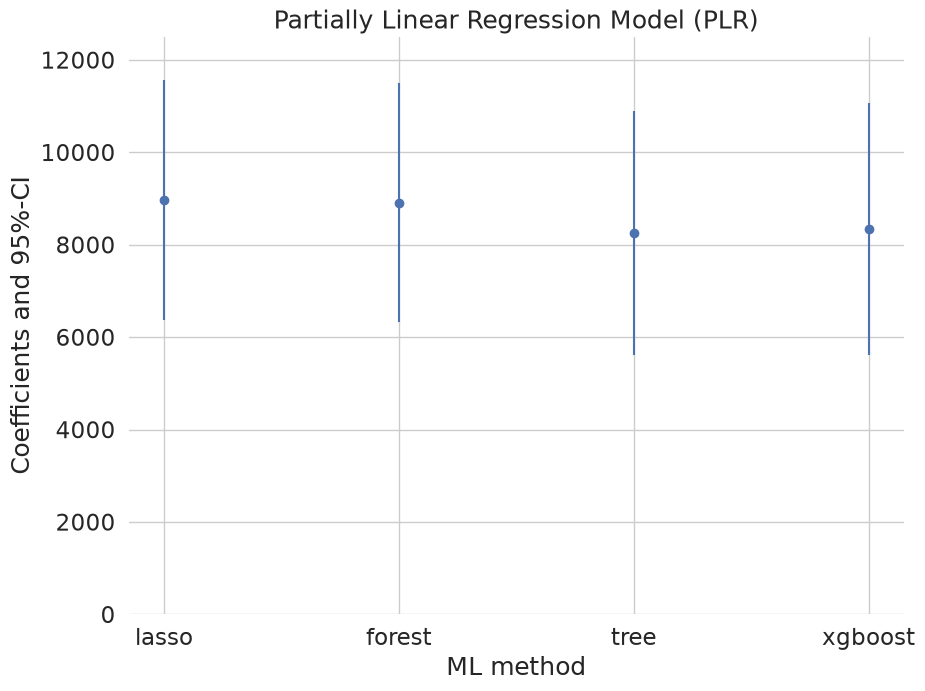

In [22]:
errors = np.full((2, plr_summary.shape[0]), np.nan)
errors[0, :] = plr_summary['coef'] - plr_summary['2.5 %']
errors[1, :] = plr_summary['97.5 %'] - plr_summary['coef']
plt.errorbar(plr_summary.index, plr_summary.coef, fmt='o', yerr=errors)
plt.ylim([0, 12500])

plt.title('Partially Linear Regression Model (PLR)')
plt.xlabel('ML method')
_ =  plt.ylabel('Coefficients and 95%-CI')

### Interactive Regression Model (IRM)

Next, we consider estimation of average treatment effects when treatment effects are fully heterogeneous:

$$
\begin{aligned}
& Y = g_0(D,X) + U, &\quad E[U\mid X,D] = 0,\\
& D = m_0(X) + V, &\quad E[V\mid X] = 0.
\end{aligned}
$$

To reduce the disproportionate impact of extreme propensity score weights in the interactive model
we trim the propensity scores which are close to the bounds.

In [23]:
# Lasso
lasso = make_pipeline(StandardScaler(), LassoCV(cv=5, max_iter=20000))

# Initialize DoubleMLIRM model
np.random.seed(123)
dml_irm_lasso = dml.DoubleMLIRM(data_dml_flex,
                          ml_g = lasso,
                          ml_m = lasso_class,
                          trimming_threshold = 0.01,
                          n_folds = 3)
dml_irm_lasso.fit(store_predictions=True) 
lasso_summary = dml_irm_lasso.summary

print(lasso_summary)

             coef      std err         t         P>|t|        2.5 %  \
e401  7763.891606  1343.034846  5.780856  7.432130e-09  5131.591678   

            97.5 %  
e401  10396.191534  


In [24]:
# Random Forest
randomForest = RandomForestRegressor(n_estimators=500)
randomForest_class = RandomForestClassifier(n_estimators=500)

np.random.seed(123)
dml_irm_forest = dml.DoubleMLIRM(data_dml_base,
                                 ml_g = randomForest,
                                 ml_m = randomForest_class,
                                 trimming_threshold = 0.01,
                                 n_folds = 3)

# Set nuisance-part specific parameters
dml_irm_forest.set_ml_nuisance_params('ml_g0', 'e401', {
    'max_depth': 6, 'max_features': 4, 'min_samples_leaf': 7})
dml_irm_forest.set_ml_nuisance_params('ml_g1', 'e401', {
    'max_depth': 6, 'max_features': 3, 'min_samples_leaf': 5})
dml_irm_forest.set_ml_nuisance_params('ml_m', 'e401', {
    'max_depth': 6, 'max_features': 3, 'min_samples_leaf': 6})

dml_irm_forest.fit(store_predictions=True) 
forest_summary = dml_irm_forest.summary

print(forest_summary)

             coef     std err         t         P>|t|        2.5 %  \
e401  8102.443032  1120.75171  7.229472  4.848757e-13  5905.810044   

            97.5 %  
e401  10299.076019  


In [25]:
# Trees
trees = DecisionTreeRegressor(max_depth=30)
trees_class = DecisionTreeClassifier(max_depth=30)

np.random.seed(123)
dml_irm_tree = dml.DoubleMLIRM(data_dml_base,
                               ml_g = trees,
                               ml_m = trees_class,
                               trimming_threshold = 0.01,
                               n_folds = 3)

# Set nuisance-part specific parameters
dml_irm_tree.set_ml_nuisance_params('ml_g0', 'e401', {
    'ccp_alpha': 0.0016, 'min_samples_split': 74, 'min_samples_leaf': 24})
dml_irm_tree.set_ml_nuisance_params('ml_g1', 'e401', {
    'ccp_alpha': 0.0018, 'min_samples_split': 70, 'min_samples_leaf': 23})
dml_irm_tree.set_ml_nuisance_params('ml_m', 'e401', {
    'ccp_alpha': 0.0028, 'min_samples_split': 167, 'min_samples_leaf': 55})

dml_irm_tree.fit(store_predictions=True)
tree_summary = dml_irm_tree.summary

print(tree_summary)

             coef      std err        t         P>|t|        2.5 %  \
e401  8059.691511  1167.841132  6.90136  5.150719e-12  5770.764953   

            97.5 %  
e401  10348.618069  


In [26]:
# Boosted Trees
boost = XGBRegressor(n_jobs=1, objective = "reg:squarederror")
boost_class = XGBClassifier(use_label_encoder=False, n_jobs=1,
                            objective = "binary:logistic", eval_metric = "logloss")

np.random.seed(123)
dml_irm_boost = dml.DoubleMLIRM(data_dml_base,
                                ml_g = boost,
                                ml_m = boost_class,
                                trimming_threshold = 0.01,
                                n_folds = 3)

# Set nuisance-part specific parameters
dml_irm_boost.set_ml_nuisance_params('ml_g0', 'e401', {
    'eta': 0.1, 'n_estimators': 8})
dml_irm_boost.set_ml_nuisance_params('ml_g1', 'e401', {
    'eta': 0.1, 'n_estimators': 29})
dml_irm_boost.set_ml_nuisance_params('ml_m', 'e401', {
    'eta': 0.1, 'n_estimators': 23})

dml_irm_boost.fit(store_predictions=True)
boost_summary = dml_irm_boost.summary

print(boost_summary)

             coef      std err         t         P>|t|        2.5 %  \
e401  8989.440854  1191.377446  7.545418  4.508390e-14  6654.383968   

            97.5 %  
e401  11324.497739  


/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [09:34:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [27]:
irm_summary = pd.concat((lasso_summary, forest_summary, tree_summary, boost_summary))
irm_summary.index = ['lasso', 'forest', 'tree', 'xgboost']
print(irm_summary[['coef', '2.5 %', '97.5 %']])

                coef        2.5 %        97.5 %
lasso    7763.891606  5131.591678  10396.191534
forest   8102.443032  5905.810044  10299.076019
tree     8059.691511  5770.764953  10348.618069
xgboost  8989.440854  6654.383968  11324.497739


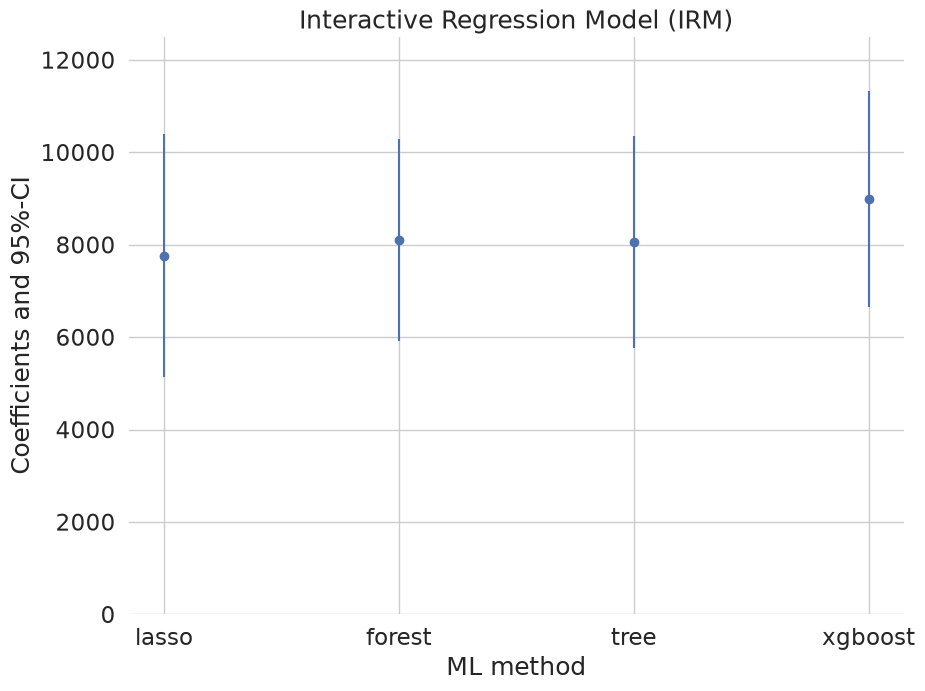

In [28]:
errors = np.full((2, irm_summary.shape[0]), np.nan)
errors[0, :] = irm_summary['coef'] - irm_summary['2.5 %']
errors[1, :] = irm_summary['97.5 %'] - irm_summary['coef']
plt.errorbar(irm_summary.index, irm_summary.coef, fmt='o', yerr=errors)
plt.ylim([0, 12500])

plt.title('Interactive Regression Model (IRM)')
plt.xlabel('ML method')
_ = plt.ylabel('Coefficients and 95%-CI')

These estimates that flexibly account for confounding are
substantially attenuated relative to the baseline estimate (*19559*) that does not account for confounding. They suggest much smaller causal effects of 401(k) eligiblity on financial asset holdings.

## Local Average Treatment Effects of 401(k) Participation on Net Financial Assets

### Interactive IV Model (IIVM)

In the examples above, we estimated the average treatment effect of *eligibility* on financial asset holdings. Now, we consider estimation of local average treatment effects (LATE) of *participation* using eligibility as an instrument for the participation decision. Under appropriate assumptions, the LATE identifies the treatment effect for so-called compliers, i.e., individuals who would only participate if eligible and otherwise not participate in the program. 

As before, $Y$ denotes the outcome `net_tfa`, and $X$ is the vector of covariates. We use `e401` as a binary instrument for the treatment variable `p401`. Here the structural equation model is:

$$
\begin{aligned}
& Y = g_0(Z,X) + U, &\quad E[U\mid Z,X] = 0,\\
& D = r_0(Z,X) + V, &\quad E[V\mid Z, X] = 0,\\
& Z = m_0(X) + \zeta, &\quad E[\zeta \mid X] = 0.
\end{aligned}
$$

In [29]:
# Initialize DoubleMLData with an instrument

# Basic model
data_dml_base_iv = dml.DoubleMLData(data,
                                    y_col='net_tfa',
                                    d_cols='p401',
                                    z_cols='e401',
                                    x_cols=features_base)

print(data_dml_base_iv)

================== DoubleMLData Object ==================

------------------ Data summary      ------------------
Outcome variable: net_tfa
Treatment variable(s): ['p401']
Covariates: ['age', 'inc', 'educ', 'fsize', 'marr', 'twoearn', 'db', 'pira', 'hown']
Instrument variable(s): ['e401']
No. Observations: 9915
------------------ DataFrame info    ------------------
<class 'pandas.DataFrame'>
RangeIndex: 9915 entries, 0 to 9914
Columns: 14 entries, nifa to hown
dtypes: float32(4), int8(10)
memory usage: 251.9 KB



In [30]:
# Flexible model
model_data = pd.concat((data.copy()[['net_tfa', 'e401', 'p401']], features.copy()),
                        axis=1, sort=False)

data_dml_iv_flex = dml.DoubleMLData(model_data,
                                    y_col='net_tfa',
                                    d_cols='p401',
                                    z_cols='e401')

print(data_dml_iv_flex)

================== DoubleMLData Object ==================

------------------ Data summary      ------------------
Outcome variable: net_tfa
Treatment variable(s): ['p401']
Covariates: ['marr', 'twoearn', 'db', 'pira', 'hown', 'age', 'age^2', 'inc', 'inc^2', 'educ', 'educ^2', 'fsize', 'fsize^2']
Instrument variable(s): ['e401']
No. Observations: 9915
------------------ DataFrame info    ------------------
<class 'pandas.DataFrame'>
RangeIndex: 9915 entries, 0 to 9914
Columns: 16 entries, net_tfa to fsize^2
dtypes: float32(3), float64(6), int8(7)
memory usage: 648.9 KB



In [31]:
# Lasso
lasso = make_pipeline(StandardScaler(), LassoCV(cv=5, max_iter=20000))

# Initialize DoubleMLIRM model
np.random.seed(123)
dml_iivm_lasso = dml.DoubleMLIIVM(data_dml_iv_flex,
                                  ml_g = lasso,
                                  ml_m = lasso_class,
                                  ml_r = lasso_class,
                                  subgroups = {'always_takers': False,
                                             'never_takers': True},
                                  trimming_threshold = 0.01,
                                  n_folds = 3)
dml_iivm_lasso.fit(store_predictions=True)
lasso_summary = dml_iivm_lasso.summary

print(lasso_summary)

              coef      std err         t         P>|t|        2.5 %  \
p401  12955.591652  1661.333581  7.798308  6.274251e-15  9699.437667   

            97.5 %  
p401  16211.745638  


Again, we repeat the procedure for the other machine learning methods:

In [32]:
# Random Forest
randomForest = RandomForestRegressor(n_estimators=500)
randomForest_class = RandomForestClassifier(n_estimators=500)

np.random.seed(123)
dml_iivm_forest = dml.DoubleMLIIVM(data_dml_base_iv,
                                   ml_g = randomForest,
                                   ml_m = randomForest_class,
                                   ml_r = randomForest_class,
                                   subgroups = {'always_takers': False,
                                                'never_takers': True},
                                   trimming_threshold = 0.01,
                                   n_folds = 3)

# Set nuisance-part specific parameters
dml_iivm_forest.set_ml_nuisance_params('ml_g0', 'p401', {
    'max_depth': 6, 'max_features': 4, 'min_samples_leaf': 7})
dml_iivm_forest.set_ml_nuisance_params('ml_g1', 'p401', {
    'max_depth': 6, 'max_features': 3, 'min_samples_leaf': 5})
dml_iivm_forest.set_ml_nuisance_params('ml_m', 'p401', {
    'max_depth': 6, 'max_features': 3, 'min_samples_leaf': 6})
dml_iivm_forest.set_ml_nuisance_params('ml_r1', 'p401', {
    'max_depth': 4, 'max_features': 7, 'min_samples_leaf': 6})

dml_iivm_forest.fit(store_predictions=True) 
forest_summary = dml_iivm_forest.summary

print(forest_summary)

              coef      std err         t         P>|t|        2.5 %  \
p401  12002.712592  1628.619613  7.369869  1.707963e-13  8810.676807   

            97.5 %  
p401  15194.748377  


In [33]:
# Trees
trees = DecisionTreeRegressor(max_depth=30)
trees_class = DecisionTreeClassifier(max_depth=30)

np.random.seed(123)
dml_iivm_tree = dml.DoubleMLIIVM(data_dml_base_iv,
                                 ml_g = trees,
                                 ml_m = trees_class,
                                 ml_r = trees_class,
                                 subgroups = {'always_takers': False,
                                              'never_takers': True},
                                 trimming_threshold = 0.01,
                                 n_folds = 3)

# Set nuisance-part specific parameters
dml_iivm_tree.set_ml_nuisance_params('ml_g0', 'p401', {
    'ccp_alpha': 0.0016, 'min_samples_split': 74, 'min_samples_leaf': 24})
dml_iivm_tree.set_ml_nuisance_params('ml_g1', 'p401', {
    'ccp_alpha': 0.0018, 'min_samples_split': 70, 'min_samples_leaf': 23})
dml_iivm_tree.set_ml_nuisance_params('ml_m', 'p401', {
    'ccp_alpha': 0.0028, 'min_samples_split': 167, 'min_samples_leaf': 55})
dml_iivm_tree.set_ml_nuisance_params('ml_r1', 'p401', {
    'ccp_alpha': 0.0576, 'min_samples_split': 55, 'min_samples_leaf': 18})

dml_iivm_tree.fit(store_predictions=True)
tree_summary = dml_iivm_tree.summary

print(tree_summary)

              coef      std err         t         P>|t|        2.5 %  \
p401  10967.290987  1751.863772  6.260356  3.840995e-10  7533.701088   

            97.5 %  
p401  14400.880886  


In [34]:
# Boosted Trees
boost = XGBRegressor(n_jobs=1, objective = "reg:squarederror")
boost_class = XGBClassifier(use_label_encoder=False, n_jobs=1,
                            objective = "binary:logistic", eval_metric = "logloss")

np.random.seed(123)
dml_iivm_boost = dml.DoubleMLIIVM(data_dml_base_iv,
                                  ml_g = boost,
                                  ml_m = boost_class,
                                  ml_r = boost_class,
                                  subgroups = {'always_takers': False,
                                               'never_takers': True},
                                  trimming_threshold = 0.01,
                                  n_folds = 3)

# Set nuisance-part specific parameters
dml_iivm_boost.set_ml_nuisance_params('ml_g0', 'p401', {
    'eta': 0.1, 'n_estimators': 9})
dml_iivm_boost.set_ml_nuisance_params('ml_g1', 'p401', {
    'eta': 0.1, 'n_estimators': 33})
dml_iivm_boost.set_ml_nuisance_params('ml_m', 'p401', {
    'eta': 0.1, 'n_estimators': 12})
dml_iivm_boost.set_ml_nuisance_params('ml_r1', 'p401', {
    'eta': 0.1, 'n_estimators': 25})

dml_iivm_boost.fit(store_predictions=True)
boost_summary = dml_iivm_boost.summary

print(boost_summary)

              coef      std err         t         P>|t|         2.5 %  \
p401  13312.769647  1672.359011  7.960474  1.713821e-15  10035.006217   

            97.5 %  
p401  16590.533077  


/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [09:35:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [09:35:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [35]:
iivm_summary = pd.concat((lasso_summary, forest_summary, tree_summary, boost_summary))
iivm_summary.index = ['lasso', 'forest', 'tree', 'xgboost']
print(iivm_summary[['coef', '2.5 %', '97.5 %']])

                 coef         2.5 %        97.5 %
lasso    12955.591652   9699.437667  16211.745638
forest   12002.712592   8810.676807  15194.748377
tree     10967.290987   7533.701088  14400.880886
xgboost  13312.769647  10035.006217  16590.533077


In [36]:
colors = sns.color_palette()

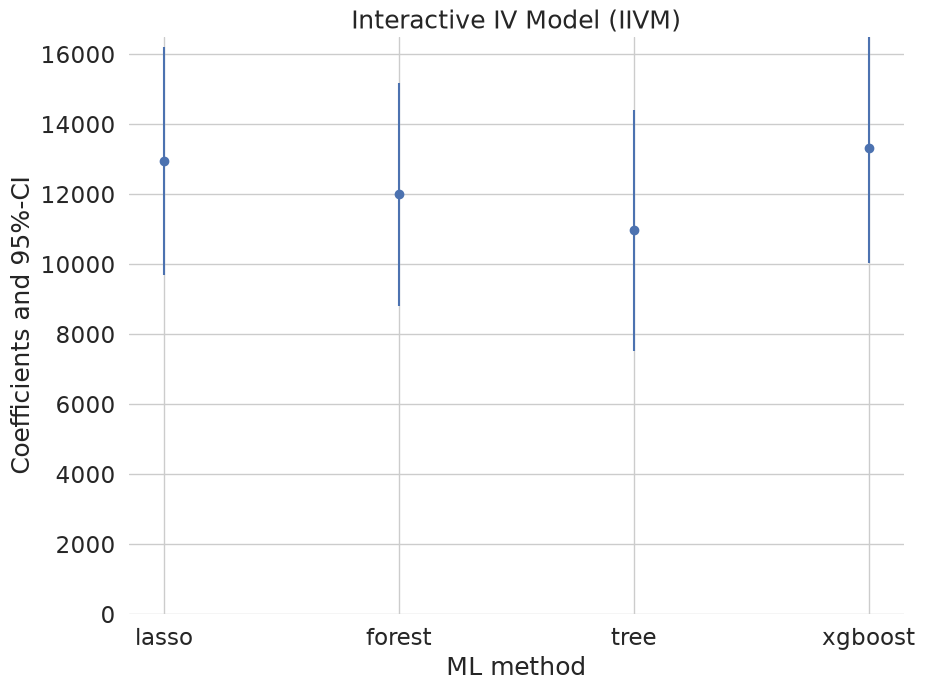

In [37]:
errors = np.full((2, iivm_summary.shape[0]), np.nan)
errors[0, :] = iivm_summary['coef'] - iivm_summary['2.5 %']
errors[1, :] = iivm_summary['97.5 %'] - iivm_summary['coef']
plt.errorbar(iivm_summary.index, iivm_summary.coef, fmt='o', yerr=errors)
plt.ylim([0, 16500])

plt.title('Interactive IV Model (IIVM)')
plt.xlabel('ML method')
_ = plt.ylabel('Coefficients and 95%-CI')

## Summary of Results

To sum up, let's merge all our results so far and illustrate them in a plot. 

In [38]:
df_summary = pd.concat((plr_summary, irm_summary, iivm_summary)).reset_index().rename(columns={'index': 'ML'})
df_summary['Model'] = np.concatenate((np.repeat('PLR', 4), np.repeat('IRM', 4), np.repeat('IIVM', 4)))
print(df_summary.set_index(['Model', 'ML']))

                       coef      std err         t         P>|t|  \
Model ML                                                           
PLR   lasso     8974.791097  1324.323636  6.776887  1.227932e-11   
      forest    8909.634078  1321.822289  6.740417  1.579322e-11   
      tree      8260.064280  1348.624798  6.124805  9.079458e-10   
      xgboost   8336.661463  1391.026647  5.993172  2.057874e-09   
IRM   lasso     7763.891606  1343.034846  5.780856  7.432130e-09   
      forest    8102.443032  1120.751710  7.229472  4.848757e-13   
      tree      8059.691511  1167.841132  6.901360  5.150719e-12   
      xgboost   8989.440854  1191.377446  7.545418  4.508390e-14   
IIVM  lasso    12955.591652  1661.333581  7.798308  6.274251e-15   
      forest   12002.712592  1628.619613  7.369869  1.707963e-13   
      tree     10967.290987  1751.863772  6.260356  3.840995e-10   
      xgboost  13312.769647  1672.359011  7.960474  1.713821e-15   

                      2.5 %        97.5 %  
Mod

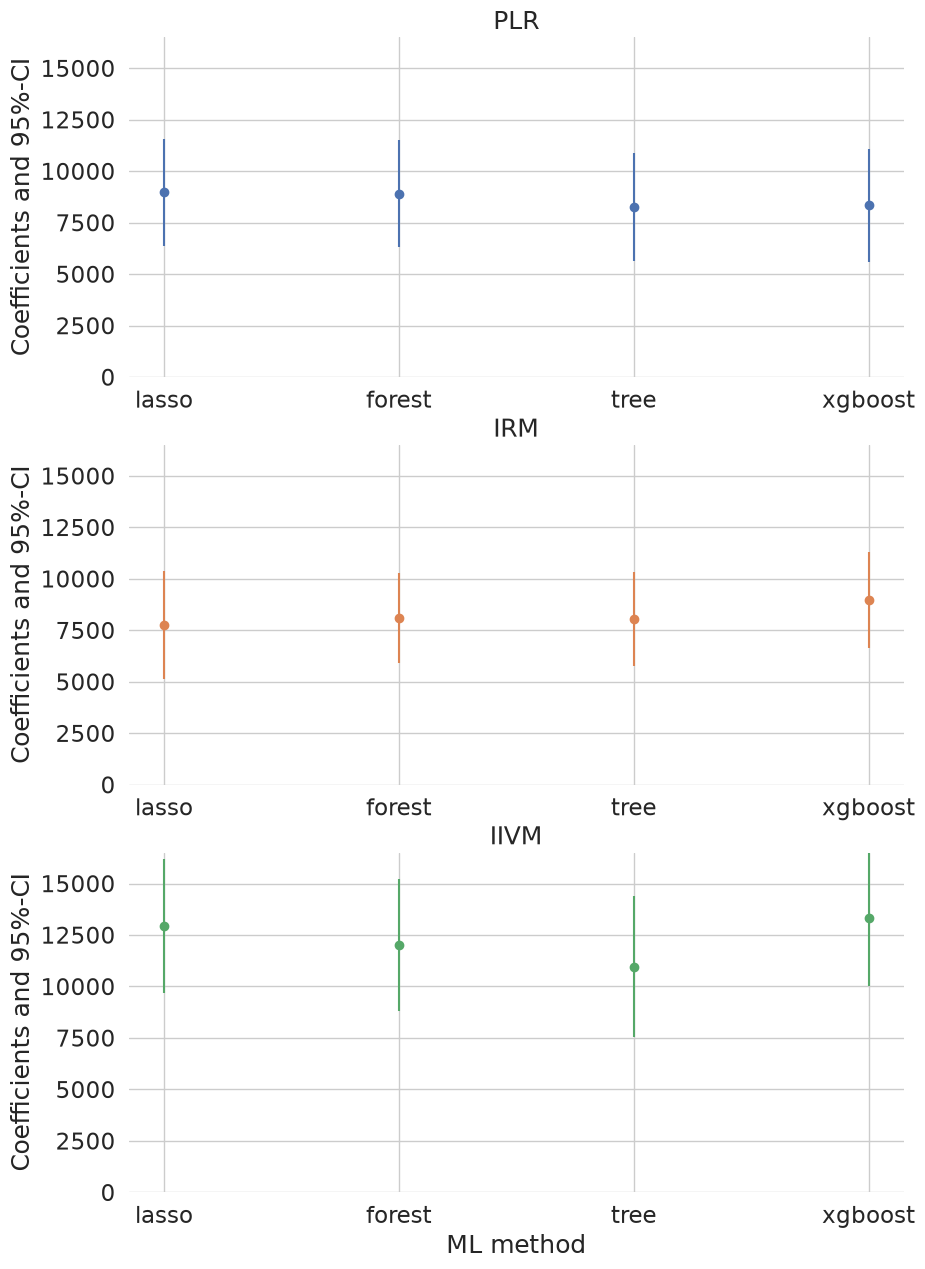

In [39]:
plt.figure(figsize=(10, 15))
colors = sns.color_palette()
for ind, model in enumerate(['PLR', 'IRM', 'IIVM']):
    plt.subplot(3, 1, ind+1)
    this_df = df_summary.query('Model == @model')
    errors = np.full((2, this_df.shape[0]), np.nan)
    errors[0, :] = this_df['coef'] - this_df['2.5 %']
    errors[1, :] = this_df['97.5 %'] - this_df['coef']
    plt.errorbar(this_df.ML, this_df.coef, fmt='o', yerr=errors,
                 color=colors[ind], ecolor=colors[ind])
    plt.ylim([0, 16500])
    plt.title(model)
    plt.ylabel('Coefficients and 95%-CI')

_ = plt.xlabel('ML method')

We report results based on four ML methods for estimating the nuisance functions used in
forming the orthogonal estimating equations. We find again that the estimates of the treatment effect are stable across ML methods. The estimates are highly significant, hence we would reject the hypothesis
that 401(k) participation has no effect on financial wealth.

______

**Acknowledgement**

We would like to thank [Jannis Kueck](https://www.dice.hhu.de/en/dice/people/professors-1/kueck) for sharing [the kaggle notebook](https://www.kaggle.com/janniskueck/pm5-401k). The pension data set has been analyzed in several studies, among others [Chernozhukov et al. (2018)](https://arxiv.org/abs/1608.00060).

